# Psilocybin, Ketamine and LSD — extracted pharmacology (v2)

**Doses, effect direction and magnitude, stated durations, and categorized adverse events,
re-extracted from raw Reddit text for a cohort that was already known to report these drugs.**

Source: `data/probes/psychedelic_pharmacology.db`, written by the second-pass probe
pipeline (`probes run psychedelic_pharmacology`). One LLM call per bounded unit of a
patient's own text; every field is source-anchored.

This is **version 2 of this study and it is not an update of version 1**. v1
(`studies/psychedelics/v1/`) analysed community-scored `drug: outcome: symptom` triples
and asked a within-patient question: does a reporter call *this* drug helpful more often
than they call *their own* other treatments helpful. That question is not answerable here,
because this dataset contains no comparator treatments — only the three target drugs. What
this dataset has instead is everything v1 was explicitly blocked on: dose, magnitude,
duration, and adverse events with a real denominator.

The two versions therefore report different things, and **their numbers are not
comparable**. v1's odds ratios stand; nothing below revises them.

---

### What is and is not claimed

Every figure here is a **share of extractable reports**, with its denominator printed next
to it. None of them is an incidence, a response rate, a probability of benefit, or a
dose-response relationship. This is a self-selected Reddit cohort of people who already
wrote about these drugs; there is no denominator of people who tried one and said nothing.

`not_stated` means the text was silent. It is never counted as an absence of adverse
events. Only `explicit_none` is a denial, and it is reported separately throughout.

---
# 1. Methods

## 1.1 Provenance

The cohort is 1,157 reporter-drug pairs over 1,041 distinct patients, imported from the
legacy pipeline's asserted cohort. For each pair the planner pulled evidence windows out of
the read-only Reddit FTS corpus (`reddit_2026-06-13.db`) and packed them into units capped
at 6,000 characters. Each unit was sent once, with retries only on failure, and the model's
response was persisted **before** validation, so failures are visible rather than silently
dropped.

The run configuration below is part of the run identity: change any of it and you get a
different `run_id` and a different database.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import psychedelics_v2 as P

P.apply_style(plt)

# The run is pinned, never chosen implicitly: load_frames raises if this id is
# absent, so re-executing against a changed database fails instead of silently
# analyzing a different run.
RUN_ID = "710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05"
f = P.load_frames(run_id=RUN_ID)   # read-only; quotes and author hashes never leave the loader

cfg = f.run["config"]
print(f"run_id      {f.run['run_id']}")
print(f"created     {f.run['created_at']}")
print(f"model       {cfg['model']}  (provider={cfg['provider']}, base={cfg['base_url']})")
print(f"temperature {cfg['temperature']}   max_tokens {cfg['max_tokens']:,}"
      f"   reasoning_effort {cfg['reasoning_effort']}")

run_id      710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05
created     2026-08-09T22:30:11.041289+00:00
model       deepseek/deepseek-v4-flash  (provider=openai, base=https://openrouter.ai/api)
temperature 0.0   max_tokens 32,768   reasoning_effort high


## 1.2 What this notebook is allowed to read

The probe database is quote-bearing by design: `source_window.text` is raw Reddit text, and
`claim.evidence_json` holds one verbatim quote per extracted field. `unit.author_hash` and
`cohort_member.author_hash` are re-identifiable.

`psychedelics_v2.load_frames()` is the only reader, and it enforces the boundary:

* `source_window.text` and `claim.evidence_json` are **never selected**;
* inside `claim.values_json`, the free-text `raw_text` / `raw_event` fields are dropped and
  only categorical and numeric fields are kept;
* `author_hash` is converted to a dense integer `patient` id inside the loader and the hash
  is discarded, so reporter-level grouping works and nothing re-identifiable exists
  downstream;
* the free-text dose fields (`unit`, `route`, `author_stated_intent`) are mapped into closed
  canonical vocabularies, so no patient-authored string is ever displayed;
* attempt error strings are bucketed into categories and the text itself is discarded, since
  a validation error can echo model output which can echo the source.

In [2]:
unsafe = {"quote", "evidence", "author_hash", "text", "raw_text", "raw_event"}
for name in ("members", "units", "attempts", "claims", "effects", "adverse", "doses"):
    cols = set(getattr(f, name).columns)
    assert not (cols & unsafe), f"{name} carries an unsafe column: {cols & unsafe}"
    print(f"{name:9s} {len(getattr(f, name)):>6,} rows   {sorted(cols)}")

members    1,157 rows   ['drug', 'patient']
units      1,206 rows   ['characters', 'drug', 'patient', 'status', 'unit_key', 'windows']
attempts   1,439 rows   ['attempt_no', 'billing_uncertain', 'cache_hit', 'failure', 'input_tokens', 'output_tokens', 'provider_cost', 'reasoning_tokens', 'status', 'unit_key']
claims     3,982 rows   ['adverse_event_status', 'claim_id', 'drug', 'exposure_status', 'included', 'n_adverse', 'n_doses', 'n_effects', 'patient', 'subject', 'unit_key']
effects    2,890 rows   ['claim_id', 'confidence', 'direction', 'drug', 'duration_bin', 'magnitude', 'magnitude_basis', 'n_symptom_labels', 'patient', 'sx_exertion_intolerance', 'sx_fatigue_general', 'sx_low_energy', 'sx_mood_cognitive', 'sx_pain', 'sx_pem_explicit', 'symptom_class']
adverse      472 rows   ['category', 'claim_id', 'confidence', 'drug', 'duration_bin', 'patient', 'severity']
doses      1,338 rows   ['amount_lower', 'amount_upper', 'claim_id', 'drug', 'has_context', 'has_formulation', 'has_schedul

## 1.3 The unit of analysis, and why the obvious one is wrong

The extraction emits one **claim** per passage discussing a target drug. 2,921 included
claims come from roughly a thousand people, so claims are **not independent**: they are
clustered inside patients, heavily and unevenly.

A proportion computed over claims is pseudo-replication. Its point estimate is a
weighted average that lets the most prolific posters vote many times, and its Wilson
interval — which assumes independent draws — is far too narrow.

So every headline rate below is computed at the **(patient, drug) pair** level: a reporter's
claims for one drug are collapsed to one value, e.g. "reported at least one helped effect
for psilocybin". Event-level tables are still shown where the shape of the data matters,
and they are always labelled event-level and never given an independence-assuming interval.

In [3]:
pde = P.patient_drug_effects(f)
share = pde.n_effects.sort_values(ascending=False)
top_pct = share.head(max(1, len(share) // 100)).sum() / share.sum()

print(f"effect records                       {len(f.effects):,}")
print(f"(patient, drug) pairs producing them {len(pde):,}")
print(f"median effect records per pair       {share.median():.0f}   max {share.max()}")
print(f"share of all effect records from the top 1% of pairs: {top_pct:.1%}")

effect records                       2,890
(patient, drug) pairs producing them 747
median effect records per pair       2   max 251
share of all effect records from the top 1% of pairs: 18.7%


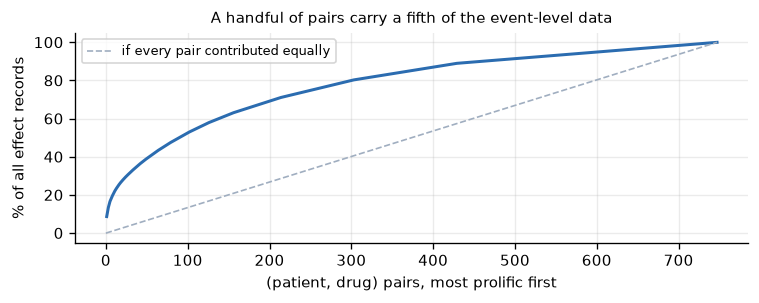

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 2.6))
ax.plot(np.arange(1, len(share) + 1), 100 * share.sort_values(ascending=False).cumsum()
        / share.sum(), color=P.COLORS["accent"], lw=1.8)
ax.plot([0, len(share)], [0, 100], color=P.COLORS["muted"], lw=1, ls="--",
        label="if every pair contributed equally")
ax.set_xlabel("(patient, drug) pairs, most prolific first")
ax.set_ylabel("% of all effect records")
ax.set_title("A handful of pairs carry a fifth of the event-level data", fontsize=9)
ax.legend(fontsize=7.5)
plt.tight_layout(); plt.show()

## 1.4 The extraction contract

Each claim carries the model's own labels for two questions it was asked to decide
semantically, with an evidence quote for each:

| field | values |
|---|---|
| `subject` | `self` / `other` / `unclear` |
| `exposure_status` | `actual_use` / `planned_or_considered` / `declined_or_never` / `unclear` |

A claim is **included** only when `subject=self` **and** `exposure_status=actual_use`.
Only included claims may carry doses, effects or adverse events; the schema rejects a
response that attaches an outcome to someone else's use or to a use that never happened.

Excluded claims are kept deliberately. They are the denominator: they show what the model
considered and set aside, which is the only way to inspect whether the inclusion rule is
doing the right thing.

---
# 2. Cohort, units and denominators

## 2.1 From cohort pairs to extracted claims

Four denominators are in play and they must not be confused: cohort pairs, planned units,
completed units, and claims. Each is smaller in a different way than the one before.

In [5]:
cohort = f.members.groupby("drug").size().rename("cohort_pairs")
units = f.units.groupby(["drug", "status"]).size().unstack(fill_value=0)
inc = f.claims[f.claims.included]

summary = pd.DataFrame({
    "cohort_pairs": cohort,
    "units_planned": f.units.groupby("drug").size(),
    "units_complete": units.get("complete", 0),
    "units_failed": units.get("failed", 0),
    "claims_total": f.claims.groupby("drug").size(),
    "claims_included": inc.groupby("drug").size(),
    "claims_excluded": f.claims[~f.claims.included].groupby("drug").size(),
    "pairs_with_included_claim": inc.groupby("drug").patient.nunique(),
}).reindex(list(P.DRUGS)).fillna(0).astype(int)
summary.loc["total"] = summary.sum()
display(summary)

print(f"distinct patients in the cohort          {f.members.patient.nunique():,}")
print(f"distinct patients with an included claim {inc.patient.nunique():,}")
print(f"source windows packed into units         {f.units.windows.sum():,}")
print(f"characters sent                          {f.units.characters.sum():,}")

,cohort_pairs,units_planned,units_complete,units_failed,claims_total,claims_included,claims_excluded,pairs_with_included_claim
drug,,,,,,,,
psilocybin,538,528,524,4,1687,1172,515,415
ketamine,525,589,581,8,2078,1588,490,463
lsd,94,89,87,2,217,161,56,75
total,1157,1206,1192,14,3982,2921,1061,953


distinct patients in the cohort          1,041
distinct patients with an included claim 878
source windows packed into units         4,180
characters sent                          2,182,844


## 2.2 What the excluded claims are

1,061 of 3,982 claims are excluded. That is not waste; it is the classifier working. The
largest single bucket by far is `unclear` on both axes (493) — passages where the text names
the drug but never anchors who took it or whether they took it. Then come the author's own
stated intention to try (217) and other people's use (261 across all statuses).

A run in which almost nothing landed in `planned_or_considered` or `other` would be evidence
the model was not really classifying. That is not what happened.

exposure_status,actual_use,declined_or_never,planned_or_considered,unclear
subject,,,,
other,151,0,27,83
self,0,18,217,57
unclear,10,0,5,493


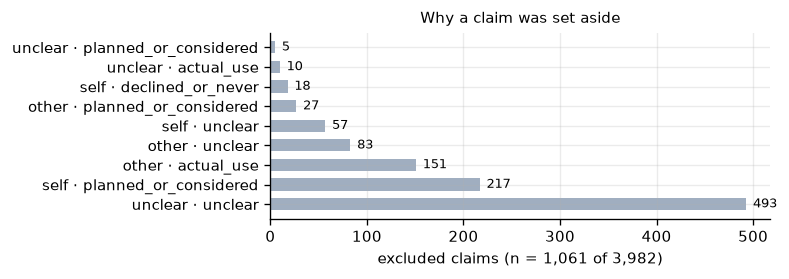

In [6]:
ex = f.claims[~f.claims.included]
tab = pd.crosstab(ex.subject, ex.exposure_status)
display(tab)

fig, ax = plt.subplots(figsize=(6.6, 2.4))
flat = tab.stack().sort_values()
flat = flat[flat > 0]
P.counts_bars(ax, [f"{s} · {st}" for s, st in flat.index], flat.values,
              color=P.COLORS["muted"])
ax.set_xlabel(f"excluded claims (n = {len(ex):,} of {len(f.claims):,})")
ax.set_title("Why a claim was set aside", fontsize=9)
plt.tight_layout(); plt.show()

## 2.3 The gap between the cohort and the analysable set

Being in the cohort does not mean producing an analysable report. A pair drops out at four
separate points: its unit can fail extraction, its text can turn out to only mention the
drug in passing, its claims can all be excluded, and even an included claim need not carry
an effect. Only the last column is what the effect-direction section actually stands on.

,cohort pairs,pairs with any claim,pairs with an included claim,pairs with an effect record,% of cohort reaching an effect
drug,,,,,
psilocybin,538,464,415,341,63.4
ketamine,525,501,463,352,67.0
lsd,94,83,75,54,57.4


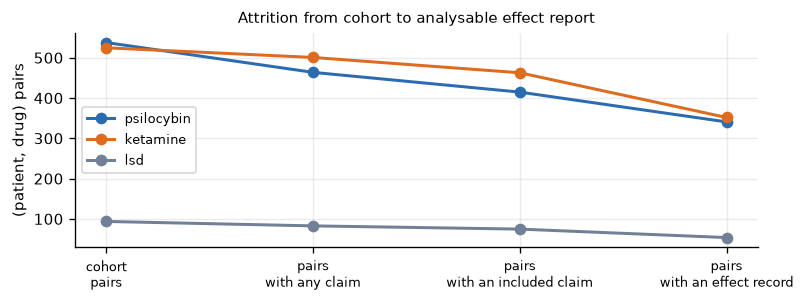

In [7]:
funnel = pd.DataFrame({
    "cohort pairs": f.members.groupby("drug").size(),
    "pairs with any claim": f.claims.groupby("drug").apply(
        lambda d: d.groupby("patient").ngroups, include_groups=False),
    "pairs with an included claim": inc.groupby("drug").apply(
        lambda d: d.groupby("patient").ngroups, include_groups=False),
    "pairs with an effect record": pde.groupby("drug").size(),
}).reindex(list(P.DRUGS)).fillna(0).astype(int)
funnel["% of cohort reaching an effect"] = (
    100 * funnel["pairs with an effect record"] / funnel["cohort pairs"]).round(1)
display(funnel)

fig, ax = plt.subplots(figsize=(6.8, 2.6))
steps = list(funnel.columns[:4])
x = np.arange(len(steps))
for d, color in zip(P.DRUGS, ["#2b6cb0", "#dd6b20", "#718096"]):
    ax.plot(x, funnel.loc[d, steps].values, "o-", color=color, lw=1.8, label=d)
ax.set_xticks(x, [s.replace(" ", "\n", 1) for s in steps], fontsize=7.5)
ax.set_ylabel("(patient, drug) pairs")
ax.set_title("Attrition from cohort to analysable effect report", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
# 3. Extraction reliability

Before any pharmacology, the machinery itself. This section is the honest part of the
paper: it says how often the extractor had to be told it was wrong, and in what way.

## 3.1 Attempts

1,206 units were planned and 1,192 completed. It took 1,439 attempts to get there — a
validation failure feeds its own error back to the model as retry feedback, up to three
attempts, and a transport failure is retried too.

In [8]:
display(P.attempt_summary(f))

apu = P.attempts_per_unit(f)
piv = apu.pivot(index="attempts", columns="status", values="units").fillna(0).astype(int)
display(piv)
print(f"units needing more than one attempt: "
      f"{int(piv.loc[piv.index > 1].values.sum())} of {len(f.units):,}")

,value
metric,
attempts,1439
accepted,1192
validation_failed,179
transport_failed,68
cache_hits,0
billing_uncertain,65
attempts with usage recorded,1374
input tokens,4540712
output tokens,6554148


status,complete,failed
attempts,,
1,1045,3
2,104,1
3,28,9
4,12,0
5,2,0
6,1,1


units needing more than one attempt: 158 of 1,206


## 3.2 Failure categories

Error strings are not shown — a validation error can quote the model's output back, which
can quote the source. They are bucketed instead.

Two things are worth reading carefully. **`outcomes_on_excluded_event`** (45 attempts) is
the model attaching a dose or effect to a passage it had itself labelled as someone else's
use or a use that never happened; the schema rejects that, and the retry usually fixes it.
**`quote_not_grounded`** (22 attempts) is the mechanical anti-fabrication floor: a quote
must share at least half its words with the window it cites. At this volume the guard is
working rather than fighting the prompt.

`connection_error` and `timeout` are transport, not model behaviour — see §3.4.

,status,failure,attempts,units
0,transport_failed,connection_error,45,27
1,transport_failed,timeout,19,17
2,transport_failed,null_content,3,3
3,transport_failed,other_schema_error,1,1
4,validation_failed,outcomes_on_excluded_event,45,41
5,validation_failed,wrong_source_reference,39,33
6,validation_failed,other_schema_error,33,31
7,validation_failed,quote_not_grounded,22,19
8,validation_failed,empty_quote,21,20
9,validation_failed,adverse_status_inconsistent,12,12


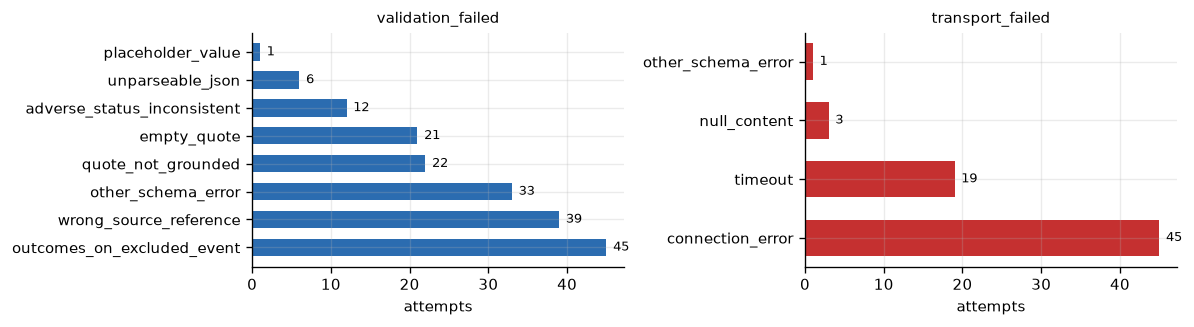

In [9]:
ft = P.failure_table(f)
display(ft)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.8))
for ax, status in zip(axes, ["validation_failed", "transport_failed"]):
    sub = ft[ft.status == status].sort_values("attempts")
    P.counts_bars(ax, sub.failure.tolist(), sub.attempts.tolist(),
                  color=P.COLORS["worsened"] if status == "transport_failed"
                  else P.COLORS["accent"])
    ax.set_xlabel("attempts")
    ax.set_title(status, fontsize=9)
plt.tight_layout(); plt.show()

## 3.3 The 14 units that never succeeded

Fourteen units exhausted their attempts and are marked `failed`. Their patients are not
necessarily absent from the analysis — a pair can span several units — but the text in
these units contributed nothing.

Eleven further units completed with **zero claims**. That is a legitimate outcome: a window
can match the drug keyword while only mentioning it in passing.

In [10]:
failed = f.units[f.units.status == "failed"]
empty = f.units[(f.units.status == "complete") & (~f.units.unit_key.isin(f.claims.unit_key))]

display(pd.DataFrame({
    "failed units": failed.groupby("drug").size(),
    "failed: patients affected": failed.groupby("drug").patient.nunique(),
    "complete but zero claims": empty.groupby("drug").size(),
}).reindex(list(P.DRUGS)).fillna(0).astype(int))

lost = failed.characters.sum()
print(f"characters in failed units: {lost:,} "
      f"({100 * lost / f.units.characters.sum():.2f}% of the corpus sent)")
print("failure category of the last attempt on each failed unit:")
last = (f.attempts[f.attempts.unit_key.isin(failed.unit_key)]
        .sort_values("attempt_no").groupby("unit_key").tail(1))
display(last.failure.value_counts().rename("units").to_frame())

,failed units,failed: patients affected,complete but zero claims
drug,,,
psilocybin,4,4,8
ketamine,8,8,2
lsd,2,2,1


characters in failed units: 58,813 (2.69% of the corpus sent)
failure category of the last attempt on each failed unit:


,units
failure,
wrong_source_reference,4
null_content,3
other_schema_error,2
outcomes_on_excluded_event,2
quote_not_grounded,2
empty_quote,1


## 3.4 Cost, tokens, and the attempts that cannot be accounted for

Reasoning tokens bill as output tokens, and at `reasoning_effort=high` they dominate: the
thinking trace is about four fifths of everything generated.

**65 attempts are `billing_uncertain`** — transport failed before usage could be read, so
they may or may not have been billed. They are named here rather than folded into a total.
Most of them come from a phase of the run when the client read timeout was 60s, which
preferentially killed long-reasoning units; the timeout was later raised to 90s and the
affected units were retried and recovered. The early attempt ledger is therefore **not a
clean sample of transport reliability**.

provider-reported cost over 1,374 attempts: $2.07
attempts with no usage recorded: 65 (of which 65 are flagged billing_uncertain)
reasoning tokens as a share of output: 79.3%
cost per completed unit: $0.0017


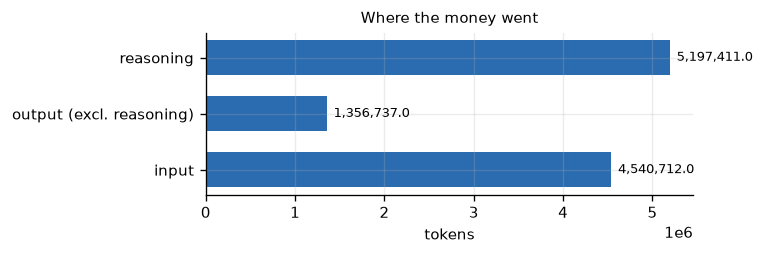

In [11]:
a = f.attempts
cost = a.provider_cost.fillna(0).sum()
print(f"provider-reported cost over {int(a.provider_cost.notna().sum()):,} attempts: "
      f"${cost:.2f}")
print(f"attempts with no usage recorded: {int(a.provider_cost.isna().sum())} "
      f"(of which {int(a.billing_uncertain.sum())} are flagged billing_uncertain)")
print(f"reasoning tokens as a share of output: "
      f"{a.reasoning_tokens.fillna(0).sum() / a.output_tokens.fillna(0).sum():.1%}")
print(f"cost per completed unit: ${cost / int((f.units.status == 'complete').sum()):.4f}")

fig, ax = plt.subplots(figsize=(6.4, 2.2))
tok = pd.Series({
    "input": a.input_tokens.fillna(0).sum(),
    "output (excl. reasoning)": a.output_tokens.fillna(0).sum() - a.reasoning_tokens.fillna(0).sum(),
    "reasoning": a.reasoning_tokens.fillna(0).sum(),
})
P.counts_bars(ax, tok.index.tolist()[::-1], tok.values.tolist()[::-1],
              color=P.COLORS["accent"])
ax.set_xlabel("tokens")
ax.set_title("Where the money went", fontsize=9)
plt.tight_layout(); plt.show()

---
# 4. Effect direction

## 4.1 Reporter-level: what share of people reported each direction

One row per (reporter, drug) pair with at least one effect record. The four categories
**overlap by construction** — a person who reports that psilocybin helped their mood and did
nothing for their fatigue appears in both `helped` and `no_effect`. They are not a partition
and do not sum to 100%.

Read these as *"of the people whose text yielded an extractable effect for this drug, this
share said it helped at least once"*. Not: how often it works.

The three drugs' any-helped shares sit close together and their intervals overlap. **That is
not evidence that they are equivalent.** No equivalence margin was prespecified and no
equivalence test was performed, so an overlap here describes the precision of these estimates
and nothing more; a clinically meaningful difference could sit comfortably inside these
intervals. The estimates and their intervals are given above to be read descriptively.

The visible difference is elsewhere: ketamine pairs report `no_effect` at roughly 29%, against
17% for psilocybin. Ketamine's dose records do state IV/IM routes far more often than the
other arms (§7), and injected use plausibly travels with a different reporting context — but
**this run records no administration-setting field**, so that is a candidate explanation for
the gap, not a measured one. Either way it concerns what gets written down rather than a
measured difference in the drugs.


,drug,direction,k,n,rate,ci_lo,ci_hi
0,psilocybin,helped,304,341,0.891,0.854,0.920
1,psilocybin,no_effect,59,341,0.173,0.137,0.217
2,psilocybin,worsened,32,341,0.094,0.067,0.129
3,psilocybin,mixed,19,341,0.056,0.036,0.085
4,ketamine,helped,294,352,0.835,0.793,0.870
5,ketamine,no_effect,103,352,0.293,0.248,0.342
6,ketamine,worsened,30,352,0.085,0.060,0.119
7,ketamine,mixed,8,352,0.023,0.012,0.044
8,lsd,helped,46,54,0.852,0.734,0.923
9,lsd,no_effect,12,54,0.222,0.132,0.349


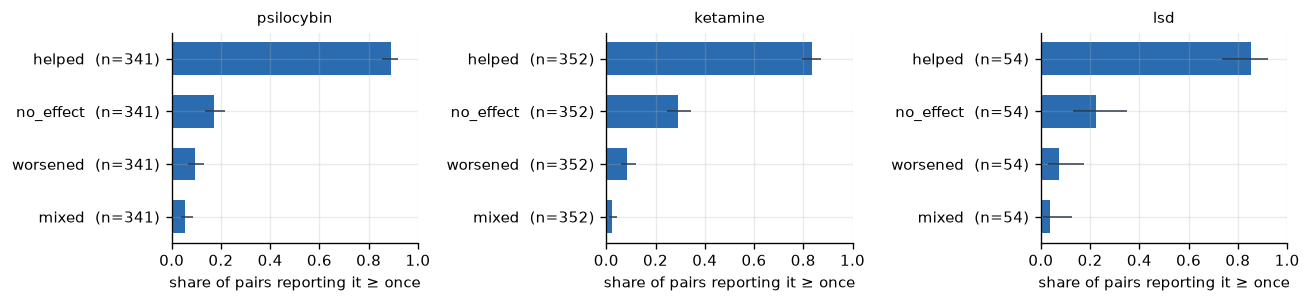

In [12]:
dm = P.direction_mix(f, level="patient")
display(dm.round(3))

fig, axes = plt.subplots(1, 3, figsize=(11, 2.6), sharex=True)
for ax, d in zip(axes, P.DRUGS):
    sub = dm[dm.drug == d]
    P.ci_bars(ax, sub.direction.tolist(), sub.rate.tolist(), sub.ci_lo.tolist(),
              sub.ci_hi.tolist(), sub.n.tolist(),
              color=P.COLORS["accent"], title=d)
    ax.set_xlabel("share of pairs reporting it ≥ once")
plt.tight_layout(); plt.show()

## 4.2 The same people, as mutually exclusive profiles

The overlap above is easier to read as a partition. Roughly two thirds of pairs report
nothing but improvement; about a fifth report a mix of directions for the same drug, which
is exactly the pattern a per-claim rate would flatten away.

profile,helped only,mixed / conflicting,no effect only,worsened only
drug,,,,
psilocybin,246,69,17,9
ketamine,225,74,40,13
lsd,38,10,6,0


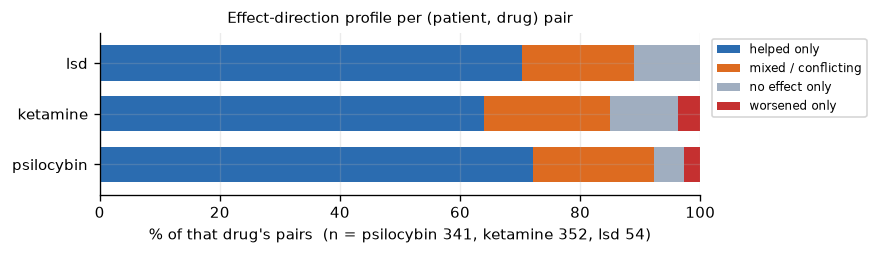

In [13]:
prof = (pde.groupby(["drug", "profile"]).size().unstack(fill_value=0)
        .reindex(index=list(P.DRUGS),
                 columns=["helped only", "mixed / conflicting", "no effect only",
                          "worsened only"], fill_value=0))
display(prof)

pct = 100 * prof.div(prof.sum(axis=1), axis=0)
ax = pct.plot(kind="barh", stacked=True, figsize=(7.4, 2.2), width=0.7,
              color=["#2b6cb0", "#dd6b20", "#a0aec0", "#c53030"])
ax.set_xlabel("% of that drug's pairs  (n = "
              + ", ".join(f"{d} {int(prof.loc[d].sum())}" for d in P.DRUGS) + ")")
ax.set_ylabel("")
ax.set_title("Effect-direction profile per (patient, drug) pair", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 4.3 Event level, for contrast — and why it is not the headline

The same data counted per effect record. The point estimate barely moves, which is not
reassurance: the two numbers answer different questions, and the event-level interval is
**wrong**, not merely different. It assumes 2,890 independent observations when the top 1%
of pairs supply nearly a fifth of them.

It is printed only so the gap between the two framings is visible.

In [14]:
ev = P.direction_mix(f, level="event")
display(ev.assign(total=ev.sum(axis=1)))

e = f.effects
k, n = int((e.direction == "helped").sum()), len(e)
est, lo, hi = P.wilson(k, n)
pl = pde
kp, np_ = int(pl.any_helped.sum()), len(pl)
estp, lop, hip = P.wilson(kp, np_)
print(f"event level   'helped' {est:.3f}  [{lo:.3f}, {hi:.3f}]  n={n:,} effect records"
      f"   ← CLUSTERED, interval is too narrow")
print(f"patient level 'any helped' {estp:.3f}  [{lop:.3f}, {hip:.3f}]  n={np_:,} pairs")
print(f"interval width: event {hi - lo:.3f}  vs  patient {hip - lop:.3f}")

direction,helped,no_effect,worsened,mixed,total
drug,,,,,
psilocybin,1135,93,61,19,1308
ketamine,1215,158,65,10,1448
lsd,110,14,8,2,134


event level   'helped' 0.851  [0.838, 0.864]  n=2,890 effect records   ← CLUSTERED, interval is too narrow
patient level 'any helped' 0.862  [0.836, 0.885]  n=747 pairs
interval width: event 0.026  vs  patient 0.049


## 4.4 What the effects were reported *about*

The model records a free-text target for about two thirds of effect records. Those strings
are never displayed; they are mapped into coarse symptom classes, and anything that does not
match one of them stays in `other`.

v1's single `energy_pem` class is not used here. One pattern matched `pem`, `fatigue`, `energy`,
`tired`, `exhaust` and `crash` together and the result was reported as post-exertional malaise,
which nonspecific tiredness does not establish. The four constructs are separated below:
`pem_explicit` needs the target to state post-exertional worsening, `exertion_intolerance` covers
exertion and exercise language without it, and `fatigue_general` and `low_energy` carry the
nonspecific remainder. Classification is also multilabel — a target naming brain fog *and*
fatigue belongs to both classes — and the table below counts each record once, under the most
specific class it matches.

The mood/cognitive class dominates, which matches v1's finding that the people who write
about these drugs in this community are carrying a heavy psychiatric load. Explicit PEM — the
class that would matter most for a specifically post-viral claim — is the smallest named class
by a wide margin, which is why the patient-experience notebook reports no PEM result.

symptom_class,pem_explicit,exertion_intolerance,fatigue_general,low_energy,mood_cognitive,pain,other,unspecified
drug,,,,,,,,
psilocybin,14,2,30,22,343,35,403,459
ketamine,26,2,53,21,334,156,383,473
lsd,1,1,12,5,26,6,47,36


,records (multilabel),reporters (multilabel)
symptom class,,
pem_explicit,41,19
exertion_intolerance,9,9
pain,197,107
mood_cognitive,730,303
fatigue_general,127,82
low_energy,67,49
other,833,292
unspecified,968,327


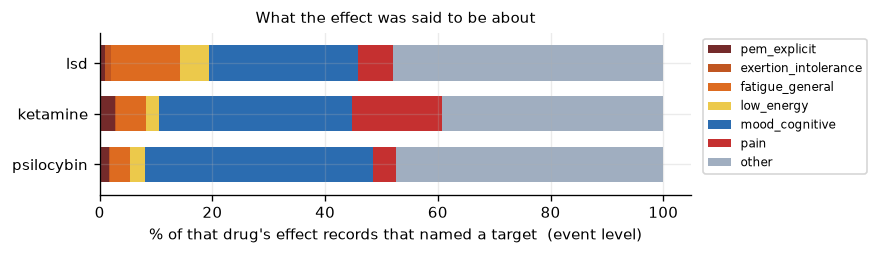

In [15]:
SYMPTOM_ORDER = ["pem_explicit", "exertion_intolerance", "fatigue_general", "low_energy",
                 "mood_cognitive", "pain", "other", "unspecified"]
assert set(SYMPTOM_ORDER) == set(P.SYMPTOM_CLASSES)
sym = (e.groupby(["drug", "symptom_class"]).size().unstack(fill_value=0)
       .reindex(index=list(P.DRUGS), columns=SYMPTOM_ORDER, fill_value=0))
display(sym)

# Multilabel membership, so a target naming two symptoms is counted under both.
display(P.symptom_composition(e)[["records (multilabel)", "reporters (multilabel)"]])

named = sym.drop(columns=["unspecified"])
pct = 100 * named.div(named.sum(axis=1), axis=0)
ax = pct.plot(kind="barh", stacked=True, figsize=(7.4, 2.2), width=0.7,
              color=["#742a2a", "#c05621", "#dd6b20", "#ecc94b",
                     "#2b6cb0", "#c53030", "#a0aec0"])
ax.set_xlabel("% of that drug's effect records that named a target  (event level)")
ax.set_ylabel("")
ax.set_title("What the effect was said to be about", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

---
# 5. Magnitude — and the two very different things it can mean

`magnitude_0_10` carries a `magnitude_basis` saying where the number came from:

* **`author_numeric`** — the author supplied a rating. This is data.
* **`model_rubric`** — the model graded the language against a rubric in the prompt. This is
  the model's reading of adjectives, and it is not evidence of the same kind.

**These must never be pooled.** There are 14 author-supplied ratings in the entire corpus
against 988 model-graded ones, so any pooled "mean magnitude" would be a statistic about the
model's rubric wearing a reporter's clothes.

In [16]:
mag = e[e.magnitude.notna()]
display(pd.crosstab(mag.magnitude_basis, mag.drug, margins=True, margins_name="total"))
print(f"effect records with any magnitude: {len(mag):,} of {len(e):,} "
      f"({len(mag) / len(e):.0%})")
print(f"author_numeric: {int((mag.magnitude_basis == 'author_numeric').sum())} records, "
      f"{mag[mag.magnitude_basis == 'author_numeric'].patient.nunique()} patients")

drug,ketamine,lsd,psilocybin,total
magnitude_basis,,,,
author_numeric,4,0,10,14
model_rubric,381,48,559,988
total,385,48,569,1002


effect records with any magnitude: 1,002 of 2,890 (35%)
author_numeric: 14 records, 13 patients


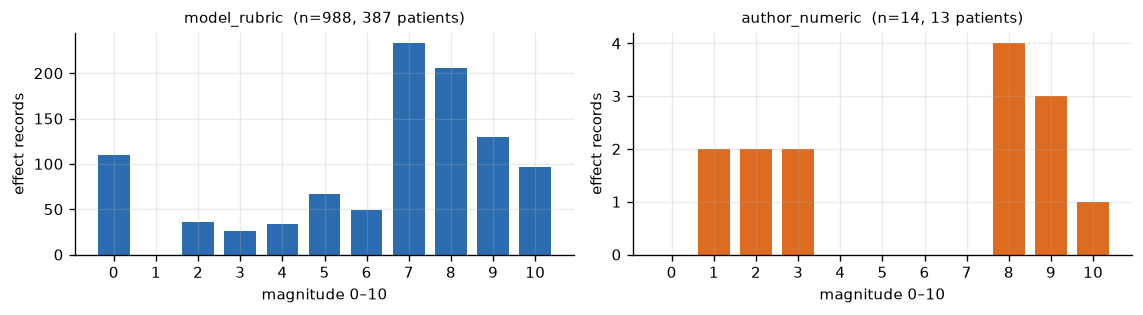

The model_rubric distribution is bimodal at 0 and 7–10, i.e. the rubric mostly
distinguishes 'nothing happened' from 'a lot happened' and rarely lands in between.
That is a property of the grader, not a measured distribution of effect sizes.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 2.7), sharey=False)
for ax, basis, color in zip(axes, ["model_rubric", "author_numeric"],
                            [P.COLORS["accent"], P.COLORS["mixed"]]):
    sub = mag[mag.magnitude_basis == basis]
    counts = sub.magnitude.value_counts().reindex(range(11), fill_value=0)
    ax.bar(counts.index, counts.values, color=color, width=0.75)
    ax.set_xticks(range(11))
    ax.set_xlabel("magnitude 0–10")
    ax.set_ylabel("effect records")
    ax.set_title(f"{basis}  (n={len(sub):,}, "
                 f"{sub.patient.nunique()} patients)", fontsize=9)
plt.tight_layout(); plt.show()

print("The model_rubric distribution is bimodal at 0 and 7–10, i.e. the rubric mostly")
print("distinguishes 'nothing happened' from 'a lot happened' and rarely lands in between.")
print("That is a property of the grader, not a measured distribution of effect sizes.")

### 5.1 Magnitude within the model-graded subset only

Restricted to `model_rubric`, split by direction, per drug. Medians, not means, and shown
with their counts: this is a description of how the grader responded to each drug's
language, offered as a check on the direction labels rather than as an effect size.

Note the `worsened` column: a bad outcome is graded *high*, because magnitude is magnitude
and not valence. Reading these numbers as "how good was it" would invert the worsening
reports.

median                            size                         
direction  helped mixed no_effect worsened helped mixed no_effect worsened
drug                                                                      
psilocybin    8.0   3.5       0.0      6.5  483.0   4.0      52.0     20.0
ketamine      7.0   2.0       0.0      7.5  322.0   1.0      52.0      6.0
lsd           7.0   NaN       0.0      7.0   41.0   NaN       6.0      1.0

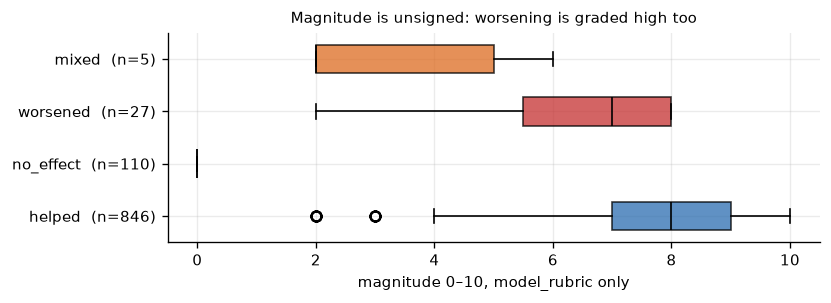

In [18]:
mr = mag[mag.magnitude_basis == "model_rubric"]
tab = mr.pivot_table(index="drug", columns="direction", values="magnitude",
                     aggfunc=["median", "size"]).reindex(list(P.DRUGS))
display(tab)

fig, ax = plt.subplots(figsize=(7, 2.6))
order = [d for d in P.DIRECTIONS if d in set(mr.direction)]
data = [mr.loc[mr.direction == d, "magnitude"].values for d in order]
bp = ax.boxplot(data, orientation="horizontal", widths=0.55, patch_artist=True,
                tick_labels=[f"{d}  (n={len(v)})" for d, v in zip(order, data)])
for patch, d in zip(bp["boxes"], order):
    patch.set_facecolor(P.COLORS.get(d, P.COLORS["muted"]))
    patch.set_alpha(0.75)
for m in bp["medians"]:
    m.set_color("black")
ax.set_xlabel("magnitude 0–10, model_rubric only")
ax.set_title("Magnitude is unsigned: worsening is graded high too", fontsize=9)
plt.tight_layout(); plt.show()

---
# 6. Stated duration

Duration was extracted **only when the author stated it**; it is never inferred from
timestamps or post dates. That makes it rare — 263 of 2,890 effect records, about 9% — and
the resulting distribution is a description of *which durations people bother to write down*,
not of how long effects last.

`acute_session` is the qualitative "during the trip" with no elapsed time attached, so it is
not on the same axis as the others and is shown separately at the left of the ordering.

duration_bin,acute_session,under_24_hours,one_to_six_days,one_to_four_weeks,one_to_six_months,over_six_months,ongoing_at_report,total
drug,,,,,,,,
psilocybin,15,26,16,41,14,9,25,146
ketamine,4,19,16,24,15,6,15,99
lsd,7,4,4,1,2,0,0,18


effect records with a stated duration: 263 of 2,890 (9.1%), from 160 patients


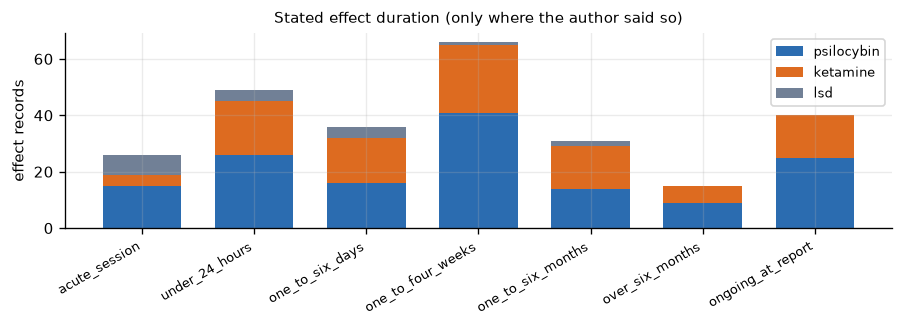

In [19]:
dur = e[e.duration_bin.notna()]
tab = (dur.groupby(["drug", "duration_bin"]).size().unstack(fill_value=0)
       .reindex(index=list(P.DRUGS), columns=list(P.DURATION_BINS), fill_value=0))
display(tab.assign(total=tab.sum(axis=1)))
print(f"effect records with a stated duration: {len(dur):,} of {len(e):,} "
      f"({len(dur) / len(e):.1%}), from {dur.patient.nunique()} patients")

fig, ax = plt.subplots(figsize=(7.6, 2.8))
bottom = np.zeros(len(P.DURATION_BINS))
x = np.arange(len(P.DURATION_BINS))
for d, color in zip(P.DRUGS, ["#2b6cb0", "#dd6b20", "#718096"]):
    v = tab.loc[d, list(P.DURATION_BINS)].values
    ax.bar(x, v, bottom=bottom, color=color, width=0.7, label=d)
    bottom += v
ax.set_xticks(x, list(P.DURATION_BINS), rotation=30, ha="right", fontsize=7.5)
ax.set_ylabel("effect records")
ax.set_title("Stated effect duration (only where the author said so)", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Adverse events carry their own duration on the same vocabulary. They sit at the short end:
about two thirds of the 129 stated adverse-event durations are under 24 hours or confined to
the session itself. That is a statement about the durations people wrote down for adverse
events, and nothing more — persistent harms are exactly the kind a person may stop posting
about.

In [20]:
ad = f.adverse[f.adverse.duration_bin.notna()]
short = ad.duration_bin.isin(["acute_session", "under_24_hours"]).sum()
display(ad.duration_bin.value_counts().reindex(list(P.DURATION_BINS)).fillna(0)
        .astype(int).rename("adverse events").to_frame())
print(f"{short} of {len(ad)} stated adverse-event durations are acute or <24h "
      f"({short / len(ad):.0%}); {len(f.adverse) - len(ad)} adverse events state no duration")

,adverse events
duration_bin,
acute_session,34
under_24_hours,49
one_to_six_days,20
one_to_four_weeks,9
one_to_six_months,4
over_six_months,4
ongoing_at_report,9


83 of 129 stated adverse-event durations are acute or <24h (64%); 343 adverse events state no duration


---
# 7. Adverse events

**Every number in this section is a share of extractable reports and carries its
denominator. None of them is an incidence.**

The schema keeps three states apart and this notebook never collapses them:

* `reported` — at least one adverse event is stated;
* `explicit_none` — the author explicitly denied adverse effects, with a quote;
* `not_stated` — **silence**. Not a denial, not an absence, not a zero.

## 7.1 The three states

Silence is overwhelming: 2,539 of 2,921 included claims — about 87% — say nothing either
way. Explicit denials (45) are rarer than reports (337) by about seven to one, which is what
you would expect from a forum where people mention side effects when they have them and
otherwise move on.

Any "adverse event rate" that divided reports by all included claims would silently be
treating those 2,539 silent claims as denials. That number is not computed here.

adverse_event_status,reported,explicit_none,not_stated,included_claims
drug,,,,
psilocybin,127,25,1020,1172
ketamine,181,19,1388,1588
lsd,29,1,131,161


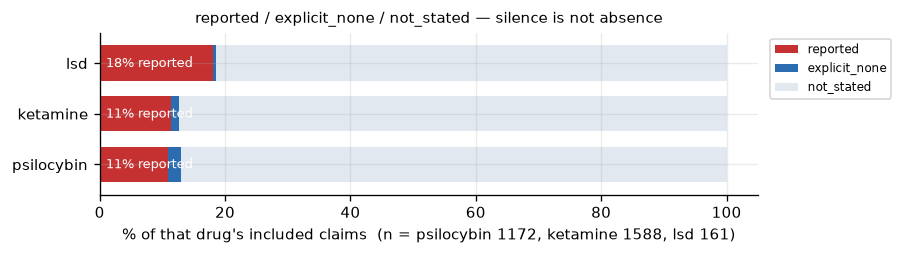

In [21]:
den = P.adverse_denominators(f)
display(den)

pct = 100 * den[list(P.AE_STATUSES)].div(den["included_claims"], axis=0)
ax = pct.plot(kind="barh", stacked=True, figsize=(7.6, 2.2), width=0.7,
              color=["#c53030", "#2b6cb0", "#e2e8f0"])
for i, d in enumerate(pct.index):
    ax.annotate(f"{pct.loc[d, 'reported']:.0f}% reported", (1, i), va="center",
                fontsize=8, color="white")
ax.set_xlabel("% of that drug's included claims  (n = "
              + ", ".join(f"{d} {int(den.loc[d, 'included_claims'])}" for d in P.DRUGS) + ")")
ax.set_ylabel("")
ax.set_title("reported / explicit_none / not_stated — silence is not absence", fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 7.2 Reporter-level: who mentioned an adverse event at all

The denominator here is **pairs with an included claim**, i.e. people whose own actual use
of that drug the extractor could confirm. The numerator is pairs whose text yielded at least
one adverse event of any category.

Ketamine (25%) sits higher than psilocybin (19%); LSD is nominally highest at 28% but on 75
pairs, and its interval spans both of the others. The same caveat as §4.1 applies with more
force here: ketamine use in this cohort is largely supervised and clinical, and clinical
settings both produce and prompt side-effect reporting. This is a difference in reporting
context before it is anything else.

,drug,k,n,rate,ci_lo,ci_hi
0,psilocybin,80,415,0.193,0.158,0.233
1,ketamine,114,463,0.246,0.209,0.287
2,lsd,21,75,0.280,0.191,0.390


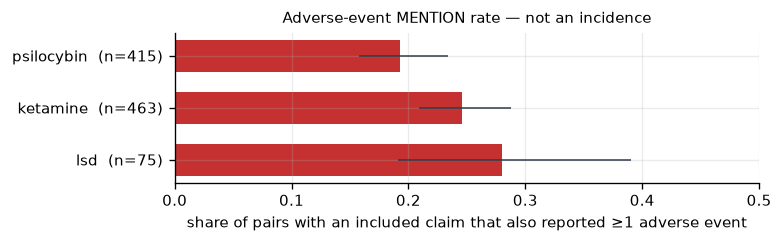

In [22]:
pairs_inc = inc.groupby(["patient", "drug"]).size().rename("claims").reset_index()
ae_pairs = set(map(tuple, f.adverse[["patient", "drug"]].drop_duplicates().values))
pairs_inc["reported_ae"] = [(p, d) in ae_pairs
                            for p, d in zip(pairs_inc.patient, pairs_inc.drug)]
rt = P.rate_table(pairs_inc, "reported_ae")
display(rt.round(3))

fig, ax = plt.subplots(figsize=(6.6, 2.1))
P.ci_bars(ax, rt.drug.tolist(), rt.rate.tolist(), rt.ci_lo.tolist(), rt.ci_hi.tolist(),
          rt.n.tolist(), color=P.COLORS["worsened"])
ax.set_xlim(0, 0.5)
ax.set_xlabel("share of pairs with an included claim that also reported ≥1 adverse event")
ax.set_title("Adverse-event MENTION rate — not an incidence", fontsize=9)
plt.tight_layout(); plt.show()

## 7.3 Categories

472 adverse-event records across 206 reporter accounts. The largest single category is `other`, at
almost half — the closed vocabulary does not fit this population well, and that is a finding
about the schema rather than about the drugs.

Among the named categories, `fatigue_pem_flare` dominates. In a post-viral cohort that
category is genuinely ambiguous: a crash after a session can be a drug effect, an
exertion-triggered flare, or the illness doing what it does. Nothing here can separate them.

,events,patients
category,,
other,227,115
fatigue_pem_flare,110,70
anxiety_panic,39,32
nausea_gi,33,23
dissociation,17,16
cardiac,15,12
headache,15,14
insomnia,10,9
derealization,6,6


472 adverse-event records from 206 patients


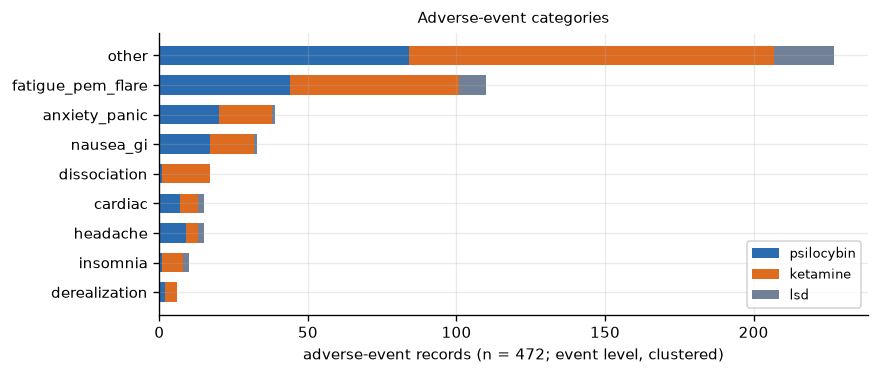

In [23]:
tot = (f.adverse.groupby("category")
       .agg(events=("claim_id", "size"), patients=("patient", "nunique"))
       .sort_values("events", ascending=False))
display(tot)
print(f"{len(f.adverse):,} adverse-event records from {f.adverse.patient.nunique()} patients")

by_drug = (f.adverse.groupby(["category", "drug"]).size().unstack(fill_value=0)
           .reindex(index=tot.index, columns=list(P.DRUGS), fill_value=0)).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.4, 3.2))
left = np.zeros(len(by_drug))
y = np.arange(len(by_drug))
for d, color in zip(P.DRUGS, ["#2b6cb0", "#dd6b20", "#718096"]):
    ax.barh(y, by_drug[d].values, left=left, color=color, height=0.66, label=d)
    left += by_drug[d].values
ax.set_yticks(y, by_drug.index)
ax.set_xlabel(f"adverse-event records (n = {len(f.adverse):,}; event level, clustered)")
ax.set_title("Adverse-event categories", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7.4 Severity

Severity is stated for 413 of 472 records. `severe` is defined in the prompt as requiring
medical care, danger, major persistent impairment, or stopping treatment — it is not a mood
word — and it accounts for about a quarter of graded records.

The 59 records with no severity are shown as their own column rather than imputed.

severity,mild,moderate,severe,not stated,total
category,,,,,
other,45,92,48,42,227
fatigue_pem_flare,25,52,23,10,110
anxiety_panic,9,19,11,0,39
nausea_gi,10,16,4,3,33
dissociation,7,6,3,1,17
cardiac,3,10,1,1,15
headache,7,4,3,1,15
insomnia,5,2,2,1,10
derealization,1,2,3,0,6


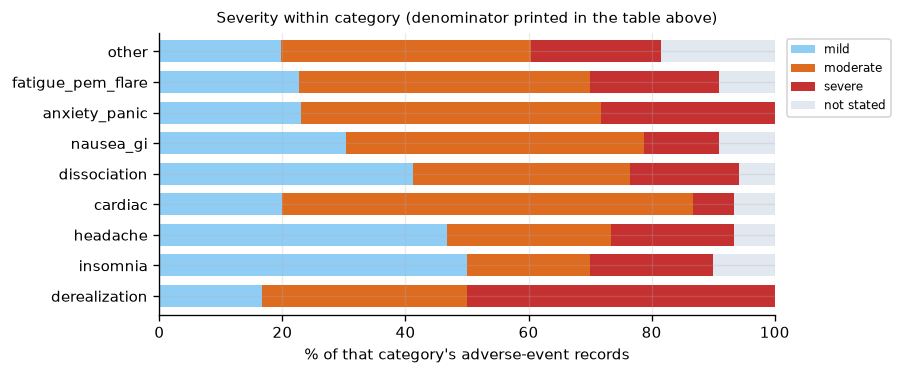

severe: 98 records from 49 patients, against 472 adverse-event records and 953 pairs with a confirmed included claim


In [24]:
sev = (pd.crosstab(f.adverse.category, f.adverse.severity.fillna("not stated"))
       .reindex(index=tot.index)
       .reindex(columns=[*P.SEVERITIES, "not stated"], fill_value=0))
display(sev.assign(total=sev.sum(axis=1)))

pct = 100 * sev.div(sev.sum(axis=1), axis=0)
ax = pct.iloc[::-1].plot(kind="barh", stacked=True, figsize=(7.6, 3.2), width=0.72,
                         color=["#90cdf4", "#dd6b20", "#c53030", "#e2e8f0"])
ax.set_xlabel("% of that category's adverse-event records")
ax.set_ylabel("")
ax.set_title("Severity within category (denominator printed in the table above)",
             fontsize=9)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

n_sev = int((f.adverse.severity == "severe").sum())
print(f"severe: {n_sev} records from {f.adverse[f.adverse.severity == 'severe'].patient.nunique()} "
      f"patients, against {len(f.adverse):,} adverse-event records and "
      f"{len(pairs_inc):,} pairs with a confirmed included claim")

---
# 8. Doses

1,338 dose records were extracted. Most of them are not numeric doses.

The extractor was told never to invent a unit or convert an amount, so a passage saying "I
microdose" produces a dose record with an intent and nothing else. That is the right
behaviour and it is why the coverage table comes first: **only 264 of 1,338 dose records
carry an amount at all, and only 273 carry a unit.** Everything downstream is conditioned on
that.

## 8.1 Coverage — what is actually populated

In [25]:
cov = P.dose_coverage(f)
display(cov)
display((100 * cov.drop(columns=["dose_records", "patients"])
         .div(cov.dose_records, axis=0)).round(1).rename(
             columns=lambda s: s.replace("with_", "% ")))

,dose_records,patients,with_amount,with_unit,with_amount_and_unit,with_route,with_intent,with_schedule,with_formulation,with_context
drug,,,,,,,,,,
psilocybin,707,291,195,200,195,109,394,157,141,59
ketamine,557,234,50,54,50,361,85,170,104,258
lsd,74,41,19,19,19,0,43,14,5,5


,% amount,% unit,% amount_and_unit,% route,% intent,% schedule,% formulation,% context
drug,,,,,,,,
psilocybin,27.6,28.3,27.6,15.4,55.7,22.2,19.9,8.3
ketamine,9.0,9.7,9.0,64.8,15.3,30.5,18.7,46.3
lsd,25.7,25.7,25.7,0.0,58.1,18.9,6.8,6.8


## 8.2 Units and routes, canonicalized

`unit` and `route` are free text: `g` / `grams` / `gram`, `IV` / `intravenous` /
`IV infusion` / `infusion`, `nasal` / `intranasal`. They are folded into closed vocabularies
by `P.canon_unit` / `P.canon_route`; anything unmatched lands in `other`, which stayed tiny.

The route split is the clearest structural fact in this dataset. Where a route was stated at
all, ketamine is overwhelmingly IV or otherwise IV/IM stated route (251 of 361) and
psilocybin is entirely oral (109 of 109); **not one LSD dose record states a route**. The
two large arms are not the same kind of exposure, and that difference sits underneath every
comparison in §4 and §7. Note the asymmetry in coverage too: 65% of ketamine dose records
state a route against 15% of psilocybin's, so this is also a picture of what each community
thinks is worth writing down.

drug,ketamine,lsd,psilocybin,total
unit_canon,,,,
count,2,8,1,11
g,0,0,160,160
mcg,0,11,0,11
mg,44,0,35,79
mg/kg,5,0,0,5
mg/ml,2,0,0,2
other,1,0,0,1
oz,0,0,4,4
total,54,19,200,273


drug,ketamine,psilocybin,total
route_canon,,,
intramuscular,10,0,10
intranasal,47,0,47
iv,251,0,251
oral,26,109,135
other,5,0,5
sublingual_buccal,22,0,22
total,361,109,470


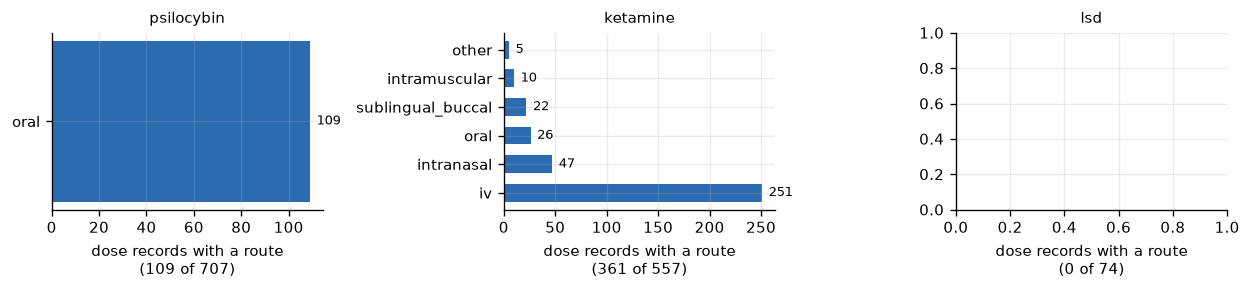

In [26]:
d = f.doses
display(pd.crosstab(d.unit_canon, d.drug, margins=True, margins_name="total"))
display(pd.crosstab(d.route_canon, d.drug, margins=True, margins_name="total"))

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.5))
for ax, drug in zip(axes, P.DRUGS):
    sub = d[(d.drug == drug) & d.route_canon.notna()]
    v = sub.route_canon.value_counts().sort_values()
    if len(v):
        P.counts_bars(ax, v.index.tolist(), v.values.tolist(), color=P.COLORS["accent"])
    ax.set_xlabel(f"dose records with a route\n({len(sub)} of {int((d.drug == drug).sum())})")
    ax.set_title(drug, fontsize=9)
plt.tight_layout(); plt.show()

## 8.3 Stated intent

`author_stated_intent` is the author's own word for what kind of dose it was, not a
computed category. Microdosing is the dominant vocabulary for psilocybin and LSD and has
essentially no ketamine equivalent — the same asymmetry v1 found in the community's drug
names, reproduced here from independent text.

In [27]:
display(pd.crosstab(d.intent_canon, d.drug, margins=True, margins_name="total"))
print(f"dose records with no stated intent: {int(d.intent_canon.isna().sum()):,} "
      f"of {len(d):,}")

drug,ketamine,lsd,psilocybin,total
intent_canon,,,,
high_dose_or_trip,8,1,31,40
low_dose,26,0,13,39
microdose,49,41,337,427
other,2,1,13,16
total,85,43,394,522


dose records with no stated intent: 816 of 1,338


## 8.4 The numeric doses that do exist

Only where an amount **and** a canonical unit were both stated. These are distributions of
*what people wrote down*, not of what people took: a memorable heroic dose is far more
likely to be written down than a routine one, so the tails are not tails of use.

Two clusters are worth naming, both on tiny denominators. Psilocybin in grams (155 records,
94 reporter accounts) is bimodal: a microdose cluster at or below half a gram, and a session cluster
in the low single digits. Ketamine in mg (42 records, 25 reporter accounts) spans more than an order
of magnitude, which is unsurprising given that IV infusion, sublingual troche and nasal
spray dosing are not on the same scale and are pooled here. A further 35 psilocybin records
state milligrams, which for a mushroom preparation is more likely a capsule label than a
psilocybin content — another reason not to read these as pharmacological doses.

In [28]:
num = d[d.amount_lower.notna() & d.unit_canon.notna()]
print(f"dose records with amount + canonical unit: {len(num):,} of {len(d):,} "
      f"({len(num) / len(d):.1%}), from {num.patient.nunique()} patients")
display(num.groupby(["drug", "unit_canon"])
        .agg(records=("amount_lower", "size"), patients=("patient", "nunique"),
             q25=("amount_lower", lambda s: s.quantile(.25)),
             median=("amount_lower", "median"),
             q75=("amount_lower", lambda s: s.quantile(.75)),
             max=("amount_lower", "max")).round(2))

dose records with amount + canonical unit: 264 of 1,338 (19.7%), from 142 patients


records  patients     q25  median    q75    max
drug       unit_canon                                                 
ketamine   count             2         2    7.00     8.0    9.0   10.0
           mg               42        25   21.25    50.0  115.0  800.0
           mg/kg             5         3    0.50     0.5    1.5    1.5
           other             1         1  200.00   200.0  200.0  200.0
lsd        count             8         3    0.50     1.0    1.0    2.0
           mcg              11         9   10.00    17.0  100.0  300.0
psilocybin count             1         1    2.00     2.0    2.0    2.0
           g               155        94    0.40     1.0    3.0   15.0
           mg               35        22   25.00   100.0  150.0  500.0
           oz                4         1    1.00     1.0    1.0    1.0

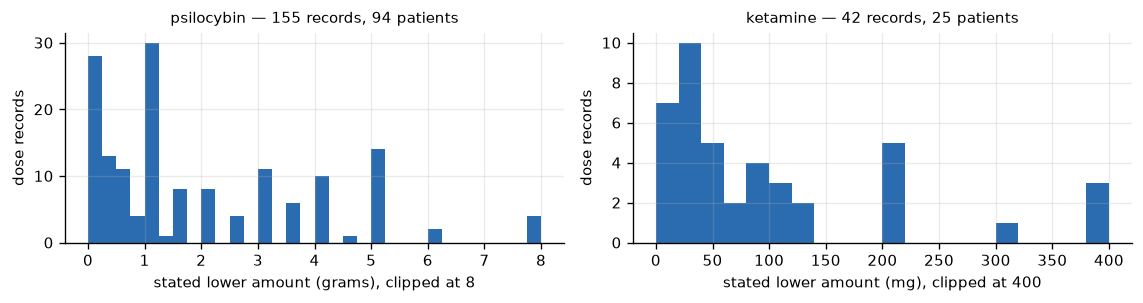

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 2.6))
specs = [("psilocybin", "g", np.arange(0, 8.25, 0.25), "grams"),
         ("ketamine", "mg", np.arange(0, 420, 20), "mg")]
for ax, (drug, unit, bins, xlabel) in zip(axes, specs):
    v = num.loc[(num.drug == drug) & (num.unit_canon == unit), "amount_lower"]
    ax.hist(v.clip(upper=bins[-1]), bins=bins, color=P.COLORS["accent"])
    ax.set_xlabel(f"stated lower amount ({xlabel}), clipped at {bins[-1]:g}")
    ax.set_ylabel("dose records")
    ax.set_title(f"{drug} — {len(v)} records, "
                 f"{num.loc[(num.drug == drug) & (num.unit_canon == unit), 'patient'].nunique()} patients",
                 fontsize=9)
plt.tight_layout(); plt.show()

---
# 9. Limitations

These are not caveats appended to a result. Several of them are load-bearing enough that the
numbers above should be read as *a description of what an unvalidated extractor produced
from a self-selected forum*, and not as measurements of anything about these drugs.

## 9.1 GATE 4 was bypassed, not satisfied

The runbook requires a human to read a sample of claims against their source windows and
confirm that each quote actually supports the field it was attached to. **That has not
happened.** No person has verified a single claim in this database at the item level.

What did run is the mechanical grounding floor: a quote must share at least half its words
with the window it cites (22 attempts were rejected for failing it, §3.2). That guard
catches fabrication. It cannot catch a real quote attached to the wrong field, a dose
credited to the wrong drug in a stack, or a plan read as a use.

Everything in sections 4 through 8 is therefore **unvalidated at the item level**. The
per-field precision and recall gates the protocol specifies — 100% quote/source integrity,
≥95% drug attribution and self-report accuracy, ≥90% precision on dose, duration and adverse
events — are unmeasured, not met.

## 9.2 The cohort was imported, so the reconciliation check is unanswered

The runbook's GATE 1 asks whether two independent derivations of the cohort agree: the
legacy pipeline's JSON-derived cohort, and this pipeline's SQL-derived one. This run's
cohort was **imported from the legacy run's JSON**, so the exact 1,157 / 538 / 525 / 94
match is true by construction and confirms nothing. The two derivations remain unreconciled.

## 9.3 An unexplained discrepancy in the planned unit set

Against the legacy reference: source windows match exactly (4,180), total characters match
exactly (2,182,844) — but this run planned **1,206** units against the legacy ~1,207, and its
largest unit is **5,998** characters against 5,990.

Identical inputs producing an identical window set and an identical character total, yet a
different packing, is not explained. It is small, but it means the two unit sets are not the
same object and a per-unit comparison across the versions is not safe.

## 9.4 The extractor is unstable at the record level

The corpus README documents two identical LLM passes over the same text agreeing on the
**field set only 36.5%** of the time and on **values 58.8%** of the time. That instability
has not been re-measured for this pipeline; no repeat-pass check was run.

The consequence is a hard rule: **cohort aggregates only.** No individual's record in this
database should be treated as a stable description of that person, and no per-person story
should be built from it. It is also a reason to read every rate here as having an error term
much larger than its Wilson interval — the interval covers sampling, not extraction noise.

## 9.5 The attempt ledger is not a clean sample

68 transport failures and 65 `billing_uncertain` attempts (§3.4). Most came from a phase of
the run when the client read timeout was 60 seconds, which preferentially killed
long-reasoning units — i.e. the failures are correlated with unit difficulty, not random.
The timeout was later raised to 90s and the affected units were retried and recovered, so
the completed set is fine; the **failure statistics** in §3.1–3.2 are not a clean sample of
anything.

## 9.6 Silence, self-selection, and the missing denominator

* The cohort is people who already wrote about these drugs on Reddit. There is no
  denominator of people who tried one and never posted, and no reason to think posting is
  independent of outcome.
* `not_stated` is silence. 87% of included claims (2,539 of 2,921) are silent on adverse
  events; none of them is evidence that nothing happened.
* Effects with no stated duration (91%) are not effects that ended quickly.
* Doses with no amount (80%) are not small doses.
* An adverse-event share is a share of **reports**, not of people who took the drug.

## 9.7 What cannot be asked of this dataset

No efficacy. No causal claim. No incidence. No dose-response, and in particular no
dose-response over time — chronology is not recoverable, because duration was taken only
from explicit statements and timestamps were deliberately not used.

There is also **no comparator arm**: unlike v1, this dataset contains only the three target
drugs, so no within-patient contrast against a reporter's own other treatments is possible
here. Differences between the three drugs in §4 and §7 are differences in reporting
context — ketamine clinical and supervised, psilocybin self-administered — at least as much
as anything else.

---
## Reproducing this notebook

```bash
cd studies/psychedelics/v2
uv run jupyter nbconvert --to notebook --execute --inplace psychedelics_v2_analysis.ipynb
uv run jupyter nbconvert --to html psychedelics_v2_analysis.ipynb
```

The database is opened read-only through a `file:…?mode=ro` URI and is never written.
`PP_PROBE_DB` overrides its location.